<a href="https://colab.research.google.com/github/Ryzhjr/floyd-warshall-project/blob/main/Jupyter_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Machine Learning Analysis of the Adult Income Dataset

Erwan Blouin

Enzo Carreiras

Emmanuel Rajaonera

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier


columns = [
    'age','workclass','fnlwgt','education','education-num','marital-status',
    'occupation','relationship','race','sex','capital-gain','capital-loss',
    'hours-per-week','native-country','income'
]


df_train = pd.read_csv("adult.data", names=columns, sep=",", skipinitialspace=True)


df_test = pd.read_csv("adult.test", names=columns, sep=",", skipinitialspace=True, skiprows=1)


df = pd.concat([df_train, df_test], axis=0)


df['income'] = df['income'].str.replace(".", "", regex=False)


df = df.replace("?", np.nan)

df.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


1. Dataset Description

The Adult Income dataset (UCI) contains 48,842 individuals described by demographic, social, and economic attributes.
The goal is to predict whether a person earns more than $50K/year.

Target Variable

income → <=50K or >50K

Feature Overview


1. age
• Type: numeric
• Description: Age of the individual

2. workclass
• Type: categorical
• Description: Type of employer

3. fnlwgt
• Type: numeric
• Description: Census sampling weight

4. education
• Type: categorical
• Description: Highest education level

5. education-num
• Type: numeric
• Description: Numeric representation of education level

6. marital-status
• Type: categorical
• Description: Marital status

7. occupation
• Type: categorical
• Description: Type of job

8. relationship
• Type: categorical
• Description: Family relationship within the household

9. race
• Type: categorical
• Description: Race of the individual

10. sex
• Type: categorical
• Description: Gender (Male/Female)

11. capital-gain
• Type: numeric
• Description: Amount of capital gain reported

12. capital-loss
• Type: numeric
• Description: Amount of capital loss reported

13. hours-per-week
• Type: numeric
• Description: Number of working hours per week

14. native-country
• Type: categorical
• Description: Country of origin

In [ ]:
print("--- Missing Values Percentage ---")
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_info = pd.DataFrame({
    'Percentage (%)': missing_percentage
}).sort_values(by='Percentage (%)', ascending=False)
print(missing_info[missing_info['Percentage (%)'] > 0])

--- Missing Values Percentage ---
                Percentage (%)
occupation            5.751198
workclass             5.730724
native-country        1.754637


In [ ]:
print("\n--- Target Variable Distribution ('income') ---")
income_counts = df['income'].value_counts()
income_counts_norm = df['income'].value_counts(normalize=True) * 100

print(income_counts)
print(income_counts_norm)


--- Target Variable Distribution ('income') ---
income
<=50K    37155
>50K     11687
Name: count, dtype: int64
income
<=50K    76.071823
>50K     23.928177
Name: proportion, dtype: float64


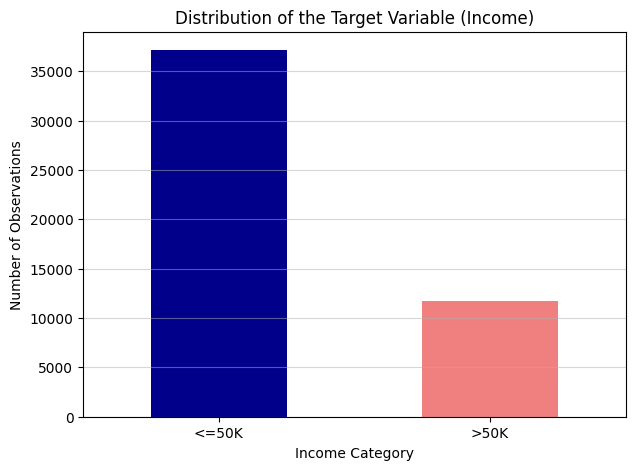

In [ ]:
plt.figure(figsize=(7, 5))
income_counts.plot(kind='bar', color=['darkblue', 'lightcoral'])
plt.title('Distribution of the Target Variable (Income)')
plt.xlabel('Income Category')
plt.ylabel('Number of Observations')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.5)
plt.show()

In [ ]:

df = df.dropna()


X = df.drop('income', axis=1)
y = df['income']


num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

num_cols, cat_cols


(Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
        'hours-per-week'],
       dtype='object'),
 Index(['workclass', 'education', 'marital-status', 'occupation',
        'relationship', 'race', 'sex', 'native-country'],
       dtype='object'))

In [ ]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


2. Preprocessing Pipeline
Steps applied:

Cleaning

Remove "?" values and problematic symbols in labels.

Handling missing data

Rows with missing values are dropped.

Column separation

Numeric vs categorical columns identified automatically.

Scaling

StandardScaler applied to numeric features (important for MLP).

Encoding

Categorical variables encoded with OneHotEncoder.

Pipeline with ColumnTransformer

Combines scaling + encoding.

Full Pipeline for each model

Pipeline([("prep", preprocessor), ("model", classifier)])

In [ ]:
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "MLP Classifier": MLPClassifier(max_iter=300)
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")

    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred, pos_label=">50K")
    }

results


Training Decision Tree...
Training Random Forest...


 3. Model Performance Metrics
Metrics used:

Accuracy – overall correctness

Precision – quality of positive predictions

Recall – ability to detect high-income individuals

F1-score – harmonic mean of precision and recall

Most important metric: F1-score

Because the dataset is imbalanced, F1-score better reflects model performance than accuracy.

4. Classification Algorithms

Three models were trained:

1. Decision Tree (mandatory)

Simple baseline

Easy to interpret

Tends to overfit

2. Random Forest

Ensemble of many trees

More stable and accurate

Good feature importance insights

3. MLPClassifier (Neural Network)

Best performance when scaled

Captures non-linear interactions

More computationally expensive

In [ ]:
for name, model in models.items():
    print(f"\n===== {name} =====")

    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))



===== Decision Tree =====

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.88      0.88      6745
        >50K       0.64      0.64      0.64      2300

    accuracy                           0.82      9045
   macro avg       0.76      0.76      0.76      9045
weighted avg       0.82      0.82      0.82      9045

Confusion Matrix:
[[5907  838]
 [ 825 1475]]

===== Random Forest =====

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      6745
        >50K       0.75      0.64      0.69      2300

    accuracy                           0.85      9045
   macro avg       0.82      0.78      0.80      9045
weighted avg       0.85      0.85      0.85      9045

Confusion Matrix:
[[6253  492]
 [ 830 1470]]

===== MLP Classifier =====

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.92      0.90    

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Final Summary

The most influential factors for income include education level, hours worked, occupation, marital status, and capital gain.

The dataset is highly imbalanced, making F1-score the most reliable evaluation metric.

Decision Tree gives a good baseline but lacks generalization.

Random Forest performs better and is more robust.

MLPClassifier achieves the best overall results thanks to scaling and one-hot encoding.

Overall, education, work intensity, and job type are strong predictors of earning more than $50K.